In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv('data/train.csv')

In [5]:
df.head()

,address,label
0,Akarca Mah. Adnan Menderes Cad. 864.Sok. No:15...,8831
1,Cumhuriye Mah. Hükümet Cad. Sivriler İşhanı No...,8810
2,İsmet inönü mahallesi 2001 sokak no:2 Çeşme be...,3067
3,"Gazeteci Hasan Tahsin Caddesi, No:10/3, Gizem...",8210
4,Bitez mahallesi Adnan Menderes caddesi gündonu...,9675


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848237 entries, 0 to 848236
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   address  848237 non-null  object
 1   label    848237 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 12.9+ MB


In [7]:
print(f"\nVeri seti {df.shape[0]} satır ve {df.shape[1]} sütundan oluşuyor.")


Veri seti 848237 satır ve 2 sütundan oluşuyor.


In [8]:
unique_labels = df['label'].nunique()
print(f"\nToplam benzersiz etiket sayısı: {unique_labels}")

print("\n--- En Sık Görülen 15 Etiket ---")
print(df['label'].value_counts().head(15))


Toplam benzersiz etiket sayısı: 10390

--- En Sık Görülen 15 Etiket ---
label
5414    536
6272    448
5591    430
3656    419
1543    412
1636    336
1563    327
5954    320
6734    300
1284    292
5748    292
5656    289
5259    282
1893    275
3658    268
Name: count, dtype: int64


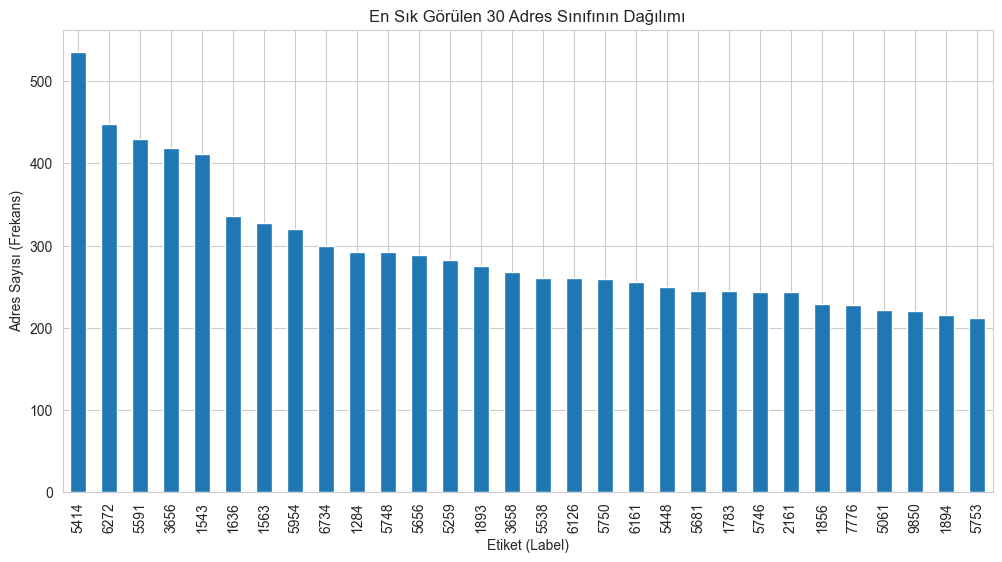

In [9]:
plt.figure(figsize=(12, 6))
df['label'].value_counts().head(30).plot(kind='bar')
plt.title('En Sık Görülen 30 Adres Sınıfının Dağılımı')
plt.xlabel('Etiket (Label)')
plt.ylabel('Adres Sayısı (Frekans)')
plt.show()

In [10]:
df['address_length'] = df['address'].str.len()

In [11]:
print("\n--- Adres Uzunluk İstatistikleri ---")
print(df['address_length'].describe())


--- Adres Uzunluk İstatistikleri ---
count    848237.000000
mean         65.024865
std          24.787421
min           1.000000
25%          48.000000
50%          62.000000
75%          80.000000
max         250.000000
Name: address_length, dtype: float64


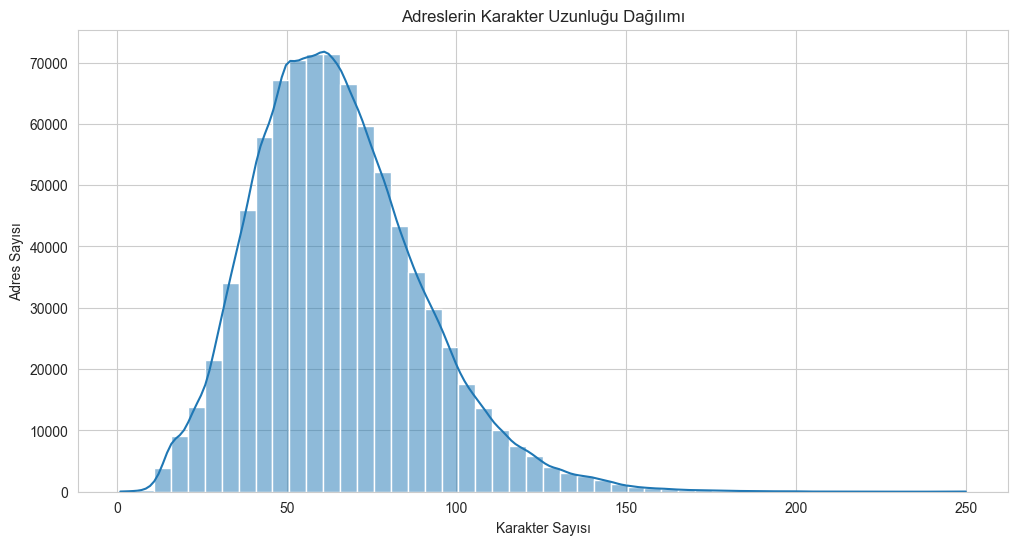

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(df['address_length'], bins=50, kde=True)
plt.title('Adreslerin Karakter Uzunluğu Dağılımı')
plt.xlabel('Karakter Sayısı')
plt.ylabel('Adres Sayısı')
plt.show()

In [13]:
vec_unigram = CountVectorizer(lowercase=True, ngram_range=(1, 1))
bow_unigram = vec_unigram.fit_transform(df['address'])
word_counts = bow_unigram.sum(axis=0)
word_freq = [(word, word_counts[0, idx]) for word, idx in vec_unigram.vocabulary_.items()]
word_freq = sorted(word_freq, key = lambda x: x[1], reverse=True)

In [14]:
print("\n--- En Yaygın 25 Kelime (Unigram) ---")
print(word_freq[:25])


--- En Yaygın 25 Kelime (Unigram) ---
[('no', np.int64(678674)), ('sokak', np.int64(313605)), ('mah', np.int64(304319)), ('mahallesi', np.int64(285393)), ('daire', np.int64(259669)), ('zmir', np.int64(228503)), ('kat', np.int64(227517)), ('sk', np.int64(116064)), ('sok', np.int64(107686)), ('caddesi', np.int64(103802)), ('sitesi', np.int64(95498)), ('blok', np.int64(93813)), ('apt', np.int64(77979)), ('muğla', np.int64(77517)), ('cad', np.int64(70591)), ('mh', np.int64(61835)), ('apartmanı', np.int64(53358)), ('izmir', np.int64(53135)), ('zmi', np.int64(51237)), ('manisa', np.int64(49926)), ('aydın', np.int64(48360)), ('atatürk', np.int64(45513)), ('denizli', np.int64(45145)), ('bornova', np.int64(41232)), ('buca', np.int64(40894))]


In [15]:
vec_bigram = CountVectorizer(lowercase=True, ngram_range=(2, 2))
bow_bigram = vec_bigram.fit_transform(df['address'])
bigram_counts = bow_bigram.sum(axis=0)
bigram_freq = [(bigram, bigram_counts[0, idx]) for bigram, idx in vec_bigram.vocabulary_.items()]
bigram_freq = sorted(bigram_freq, key = lambda x: x[1], reverse=True)

In [16]:
print("\n--- En Yaygın 25 Kelime Grubu (Bigram) ---")
print(bigram_freq[:25])


--- En Yaygın 25 Kelime Grubu (Bigram) ---
[('sokak no', np.int64(209985)), ('kat daire', np.int64(111683)), ('sk no', np.int64(72875)), ('sok no', np.int64(70882)), ('caddesi no', np.int64(54168)), ('no kat', np.int64(41768)), ('cad no', np.int64(37864)), ('no daire', np.int64(37572)), ('blok kat', np.int64(26314)), ('sitesi blok', np.int64(25835)), ('bornova zmir', np.int64(22303)), ('bodrum muğla', np.int64(21179)), ('no 10', np.int64(20810)), ('buca zmir', np.int64(20560)), ('apt no', np.int64(19982)), ('blok daire', np.int64(18097)), ('no 11', np.int64(17831)), ('karabağlar zmir', np.int64(17573)), ('no 12', np.int64(17194)), ('konak zmir', np.int64(16254)), ('zmir türkiye', np.int64(15875)), ('daire no', np.int64(15503)), ('merkezefendi denizli', np.int64(14875)), ('dai re', np.int64(14868)), ('no 14', np.int64(14796))]


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    df['address'], 
    df['label'],
    test_size=0.20, 
    random_state=42,
    stratify=df['label']
)

print("\n--- Veri Bölme Sonuçları ---")
print(f"Orijinal veri seti boyutu: {len(df)}")
print(f"Eğitim seti boyutu (X_train): {len(X_train)}")
print(f"Doğrulama seti boyutu (X_val): {len(X_val)}")


--- Veri Bölme Sonuçları ---
Orijinal veri seti boyutu: 848237
Eğitim seti boyutu (X_train): 678589
Doğrulama seti boyutu (X_val): 169648


# FEATURE ENGINEERING

In [20]:
import re
import unicodedata

In [21]:
def turkish_lower(text):
    text = text.replace('I', 'ı')
    text = text.replace('İ', 'i')
    return text.lower()

def temel_temizleme(text):
    # 1. Gelen metnin string olduğundan emin ol (bazen NaN gelebilir)
    if not isinstance(text, str):
        return ""
    
    # 2. Türkçe'ye özgü küçük harfe çevirme
    text = turkish_lower(text)
    
    # 3. Noktalama işaretlerini boşlukla değiştir. Sayılar arasındaki '.' veya '/' kalabilir.
    # Örn: "No:15/A" -> "no 15 a", "864.Sok." -> "864 sok"
    text = re.sub(r'[^a-z0-9ıöüçğş\s]', ' ', text)
    
    # 4. Fazla boşlukları tek boşluğa indir
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Fonksiyonu test edelim
ornek_adres = "Akarca Mah. Adnan Menderes Cad. 864.Sok. No:15 D.1 K.2 ."
temizlenmis_adres = temel_temizleme(ornek_adres)
print(f"Orijinal: '{ornek_adres}'")
print(f"Temizlenmiş: '{temizlenmis_adres}'")

# Şimdi tüm veri setine uygulayalım
# Faz 1'den gelen X_train ve X_val'i kullanıyoruz
# NOT: Eğer Faz 1'i çalıştırmadıysan, önce onu çalıştırıp X_train ve X_val'i oluşturmalısın.
X_train_temiz = X_train.apply(temel_temizleme)
X_val_temiz = X_val.apply(temel_temizleme)

print("\n--- İlk 5 Temizlenmiş Eğitim Verisi ---")
print(X_train_temiz.head())

Orijinal: 'Akarca Mah. Adnan Menderes Cad. 864.Sok. No:15 D.1 K.2 .'
Temizlenmiş: 'akarca mah adnan menderes cad 864 sok no 15 d 1 k 2'

--- İlk 5 Temizlenmiş Eğitim Verisi ---
174486    yıldız mah 206 64 sok üçbahçe evleri sitesi 6 ...
499177                   reisdere mahallesi 6014 sokak no 8
845902    186 sk cafer kasapoğlu apartmanı no 10 kat 1 k...
753583    güvendik mah mehmet ali aygüven cad no 205 çeş...
252448      menderes mah 157 1 sok no 34 k 4 d 8 buca izmir
Name: address, dtype: object
